In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
df = pd.read_csv('Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
df['Species'] = encoder.fit_transform(df['Species'])

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [11]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

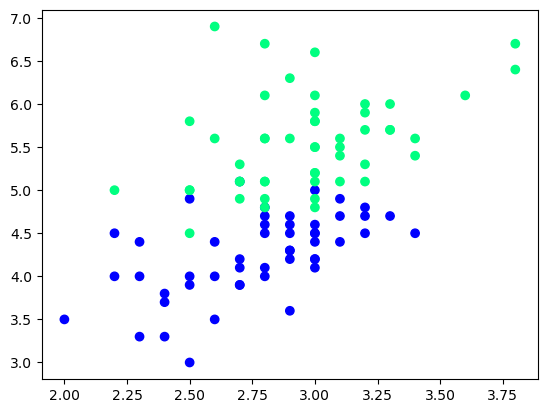

In [13]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [14]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
70,3.2,4.8,1
95,3.0,4.2,1
60,2.0,3.5,1
91,3.0,4.6,1
77,3.0,5.0,1
94,2.7,4.2,1
84,3.0,4.5,1
50,3.2,4.7,1
85,3.4,4.5,1
73,2.8,4.7,1


In [15]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [16]:
df_train

,SepalWidthCm,PetalLengthCm,Species
113,2.5,5.0,2
129,3.0,5.8,2
92,2.6,4.0,1
116,3.0,5.5,2
126,2.8,4.8,2
84,3.0,4.5,1
108,2.5,5.8,2
127,3.0,4.9,2
139,3.1,5.4,2
95,3.0,4.2,1


In [17]:
df_val

,SepalWidthCm,PetalLengthCm,Species
134,2.6,5.6,2
140,3.1,5.6,2
57,2.4,3.3,1
132,2.8,5.6,2
143,3.2,5.9,2


In [18]:
df_test

,SepalWidthCm,PetalLengthCm,Species
65,3.1,4.4,1
68,2.2,4.5,1
115,3.2,5.3,2
141,3.1,5.1,2
135,3.0,6.1,2


In [19]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [20]:
y_test

array([2, 2, 1, 2, 2])

# Case 1 - Bagging

In [21]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
126,2.8,4.8,2
84,3.0,4.5,1
84,3.0,4.5,1
92,2.6,4.0,1
108,2.5,5.8,2
108,2.5,5.8,2
129,3.0,5.8,2
113,2.5,5.0,2


In [23]:
%conda install mlxtend

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.1

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/peeyush/anaconda3

  added / updated specs:
    - mlxtend


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    mlxtend-0.23.4             |  py313h06a4308_1         1.4 MB
    ------------------------------------------------------------
                                           Total:         1.4 MB

The following NEW packages will be INSTALLED:

  mlxtend            pkgs/main/linux-64::mlxtend-0.23.4-py313h06a4308_1 



                                                                                
Preparing transaction: done
Ve

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [25]:
dt_bag1 = DecisionTreeClassifier()

In [26]:
evaluate(dt_bag1,X,y)

NameError: name 'evaluate' is not defined

In [27]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
92,2.6,4.0,1
126,2.8,4.8,2
126,2.8,4.8,2
92,2.6,4.0,1
108,2.5,5.8,2
116,3.0,5.5,2
129,3.0,5.8,2
127,3.0,4.9,2


In [28]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

NameError: name 'evaluate' is not defined

In [29]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
108,2.5,5.8,2
108,2.5,5.8,2
113,2.5,5.0,2
116,3.0,5.5,2
92,2.6,4.0,1
84,3.0,4.5,1
139,3.1,5.4,2
126,2.8,4.8,2


In [30]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

NameError: name 'evaluate' is not defined

In [31]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [32]:
df_test

,SepalWidthCm,PetalLengthCm,Species
65,3.1,4.4,1
68,2.2,4.5,1
115,3.2,5.3,2
141,3.1,5.1,2
135,3.0,6.1,2


In [34]:
# Fit the estimators before prediction
for clf in (dt_bag1, dt_bag2, dt_bag3):
    if not hasattr(clf, "tree_"):
        clf.fit(X, y)

print("Predictor 1", dt_bag1.predict(np.array([2.2, 5.0]).reshape(1, 2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/peeyush/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [35]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
113,2.5,5.0,2
129,3.0,5.8,2
92,2.6,4.0,1
116,3.0,5.5,2
126,2.8,4.8,2
84,3.0,4.5,1
108,2.5,5.8,2
127,3.0,4.9,2
139,3.1,5.4,2
95,3.0,4.2,1


In [36]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
84,3.0,4.5,1
127,3.0,4.9,2
129,3.0,5.8,2
126,2.8,4.8,2
139,3.1,5.4,2
113,2.5,5.0,2
95,3.0,4.2,1
116,3.0,5.5,2


# Random Subspaces

In [38]:
df1 = pd.read_csv('Iris.csv')
df1 = df1.sample(10)

In [39]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
16,17,5.4,3.9,1.3,0.4,Iris-setosa
118,119,7.7,2.6,6.9,2.3,Iris-virginica
61,62,5.9,3.0,4.2,1.5,Iris-versicolor
130,131,7.4,2.8,6.1,1.9,Iris-virginica
14,15,5.8,4.0,1.2,0.2,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
73,74,6.1,2.8,4.7,1.2,Iris-versicolor
144,145,6.7,3.3,5.7,2.5,Iris-virginica
60,61,5.0,2.0,3.5,1.0,Iris-versicolor
114,115,5.8,2.8,5.1,2.4,Iris-virginica


In [40]:
df1.sample(2,replace=True,axis=1)

,PetalLengthCm,PetalWidthCm
16,1.3,0.4
118,6.9,2.3
61,4.2,1.5
130,6.1,1.9
14,1.2,0.2
62,4.0,1.0
73,4.7,1.2
144,5.7,2.5
60,3.5,1.0
114,5.1,2.4


# Random Patches

In [41]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
16,17,5.4,3.9,1.3,0.4,Iris-setosa
118,119,7.7,2.6,6.9,2.3,Iris-virginica
61,62,5.9,3.0,4.2,1.5,Iris-versicolor
130,131,7.4,2.8,6.1,1.9,Iris-virginica
14,15,5.8,4.0,1.2,0.2,Iris-setosa
62,63,6.0,2.2,4.0,1.0,Iris-versicolor
73,74,6.1,2.8,4.7,1.2,Iris-versicolor
144,145,6.7,3.3,5.7,2.5,Iris-virginica
60,61,5.0,2.0,3.5,1.0,Iris-versicolor
114,115,5.8,2.8,5.1,2.4,Iris-virginica


In [42]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,Species,PetalWidthCm
144,Iris-virginica,2.5
16,Iris-setosa,0.4
14,Iris-setosa,0.2
16,Iris-setosa,0.4
16,Iris-setosa,0.4
60,Iris-versicolor,1.0
114,Iris-virginica,2.4
14,Iris-setosa,0.2
